A note book for documenting qualitative results

In [15]:
import os
import matplotlib.pyplot as plt
import torchvision
import torch
import pandas as pd
import numpy as np

from models import get_inception_transform
from data_loaders import CUB_extnded_dataset,CUB_CtoY_dataset
from IPython.display import display
from utils.notebook import display_scrollable_dataframe,plot_sailency
from sailency import get_saliency_maps,saliency_score_part

In [2]:
# Settings for the experiment your running
data_set = 'test' 

#Make the dataset
transform = get_inception_transform(mode=data_set, methode= "center")

majority_config = {'CUB_dir':r'data/CUB_200_2011',
                'split_file':r'data/train_test_val.pkl',
                'use_majority_voting':True,
                'min_class_count':10,
                'return_visibility':False}

NoN_majority_config = {'CUB_dir':r'data/CUB_200_2011',
                'split_file':r'data/train_test_val.pkl',
                'use_majority_voting':False,
                'min_class_count':10,
                'return_visibility':False}


#Make the majority dataset and find the mask, we use CtoY dataset so we only need to loade the image ones 
Majority_dataset = CUB_extnded_dataset(mode=data_set,config_dict=majority_config,transform=transform)
mask = Majority_dataset.concept_mask

#Make dataloader that return non standarized images
human_tansform = torchvision.transforms.Compose([torchvision.transforms.CenterCrop(299),torchvision.transforms.ToTensor()])
data_human = CUB_extnded_dataset(mode=data_set,config_dict=NoN_majority_config,transform=human_tansform)

#Define usefull variables
concept_names = Majority_dataset.consept_labels_names
class_names = Majority_dataset.class_labels_names
n_classes = Majority_dataset.n_classes
n_concepts = Majority_dataset.n_concepts

print(f"Number of classes: {n_classes}")
print(f"Number of concepts: {n_concepts}")

Number of classes: 200
Number of concepts: 112


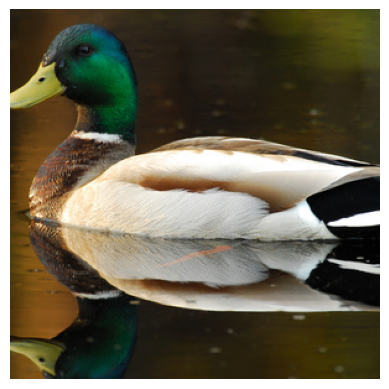

In [3]:
# Genrate the dataset
picturer_idx = 2463

#Show image with human transform
img_original ,_,Y,coordinates = data_human.__getitem__(picturer_idx)

# Show the image and the coordinates of the concepts
plt.imshow(img_original.permute(1, 2, 0))
plt.axis('off')
plt.show()

#Load the data
X_original, C, Y,_ = Majority_dataset.__getitem__(picturer_idx)

# Separate the concepts and their visibility only relevant if visibility is used and no majority voting is used
if len(C.shape) == 2:
    Concepts = C[0]
    Concepts_visiblity = C[1]
else:
    Concepts = C.tolist()
    Concepts_visiblity = [None]*len(C)




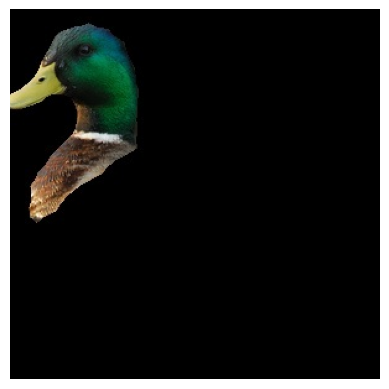

In [16]:
#Load manipulated image and transform it to the same size as the original image
from PIL import Image
ind = Image.open("Mallard_Manipulated2.jpg")
img_manipulated = human_tansform(ind)
X_manipulated = transform(ind)

plt.imshow(img_manipulated.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [5]:
#Make concept dictionary
"""
concept_prediction = concept_prediction[0].detach()
concepts_propebability = torch.sigmoid(concept_prediction)
pridicted_class = Majority_dataset.concepts[Y]
#Apply mask
if concept_prediction.shape != Majority_C.shape:
    concept_prediction = concept_prediction[mask]
    concepts_propebability = concepts_propebability[mask]
"""


#Get ture labels 
_,NoN_Majority_C,_,_ = data_human.__getitem__(picturer_idx)
_,Majority_C,_,_ = Majority_dataset.__getitem__(picturer_idx)

#Find distribution of the concepts
Majority_concepts = Majority_dataset.concepts
NoN_Majority_concepts = np.array([data_human.concepts[y] for y in data_human.concepts.keys()])


Concept_dict={"Concept":concept_names,
                    "Label": NoN_Majority_C[mask].numpy().astype(bool),
                    #"Label distribution": np.mean(NoN_Majority_concepts,axis=0)[mask],
                    "Majority Label": Majority_C.numpy().astype(bool),
                    #"Majority ditribution": np.mean(Majority_concepts,axis=0)
                      }
    


  

In [6]:
# Test the concept model with majority voting
XtoC_Model = torch.load(r'Original_models\Original_concepts\best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'Original_models\Original_independent\best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()

#Make prediction
C_hat = XtoC_Model(X_original.unsqueeze(0))
C_hat_probability = torch.sigmoid(C_hat)

Y_hat = torch.softmax(CtoY_Model(C_hat_probability),dim=1)

print(f"Predicted class: {class_names[Y_hat.argmax().item()]} true class: {class_names[Y.argmax().item()]} probability of true class: {Y_hat[0,Y.argmax()].item()}")

#Make Concept prediction and other stuff
weights = CtoY_Model.linear.weight[Y.argmax().item()]

Concept_dict["Original"] = np.round(C_hat.detach().numpy()[0],2)
#display_scrollable_dataframe(pd.DataFrame(Concept_dict).sort_values(by=['Majority Label',"Label"],ascending=False))





c:\Users\Andre\OneDrive - Danmarks Tekniske Universitet\MasterThesis\concept_bottleneck\env\Lib\site-packages\torch\serialization.py:1580: SourceChangeWarning: source code of class 'CUB.template_model.Inception3' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
c:\Users\Andre\OneDrive - Danmarks Tekniske Universitet\MasterThesis\concept_bottleneck\env\Lib\site-packages\torch\serialization.py:1580: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
c:\Users\Andre\OneDrive - Danmarks Tekniske Universitet\MasterThesis\concept_bottleneck\env\Lib\site-packages\tor

Predicted class: 087.Mallard true class: 087.Mallard probability of true class: 0.7927848100662231


In [7]:
# Test the concept model with majority voting
XtoC_Model = torch.load(r'Original_models\Original_concepts\best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'Original_models\Original_independent\best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()

#Make prediction
C_hat = XtoC_Model(X_manipulated.unsqueeze(0))
C_hat_probability = torch.sigmoid(C_hat)

Y_hat = torch.softmax(CtoY_Model(C_hat_probability),dim=1)

print(f"Predicted class: {class_names[Y_hat.argmax().item()]} true class: {class_names[Y.argmax().item()]} probability of true class: {Y_hat[0,Y.argmax()].item()}")

#Make Concept prediction and other stuff
weights = CtoY_Model.linear.weight[Y.argmax().item()]


Concept_dict["Minipulated"] = np.round(C_hat.detach().numpy()[0],2)

Predicted class: 087.Mallard true class: 087.Mallard probability of true class: 0.7777637839317322


In [8]:
#Add the baslines
Concept_dict["NoN-MV Label distribution"] = np.mean(NoN_Majority_concepts,axis=0)[mask]
Concept_dict["MV label ditribution"] = np.mean(Majority_concepts,axis=0)


In [9]:
#Find ellemnt in concept dict of wrong length

for key in Concept_dict.keys():
    if len(Concept_dict[key]) != len(concept_names):
        print(key,Concept_dict[key].shape)

In [10]:
Full_df=pd.DataFrame(Concept_dict)

#Show 5 most pedicted concepts in original and manipultated 
display_scrollable_dataframe(Full_df.sort_values(by=['Original'],ascending=False).head(5))
display_scrollable_dataframe(Full_df.sort_values(by=['Minipulated'],ascending=False).head(5))

,Concept,Label,Majority Label,Original,Minipulated,NoN-MV Label distribution,MV label ditribution
81,has_shape::duck-like,True,True,12.96,4.66,0.061334,0.050
85,has_back_pattern::multi-colored,False,True,11.58,5.94,0.194774,0.070
16,has_underparts_color::brown,True,True,11.51,4.77,0.102732,0.060
39,has_breast_color::brown,True,True,11.48,4.59,0.113590,0.065
62,has_under_tail_color::white,False,True,10.80,5.11,0.179080,0.160


,Concept,Label,Majority Label,Original,Minipulated,NoN-MV Label distribution,MV label ditribution
85,has_back_pattern::multi-colored,False,True,11.58,5.94,0.194774,0.070
111,has_wing_pattern::multi-colored,True,True,9.46,5.71,0.297336,0.220
8,has_wing_color::white,True,True,9.98,5.43,0.260774,0.205
14,has_upperparts_color::white,True,True,10.32,5.40,0.232949,0.175
38,has_head_pattern::plain,True,True,8.82,5.38,0.263828,0.215


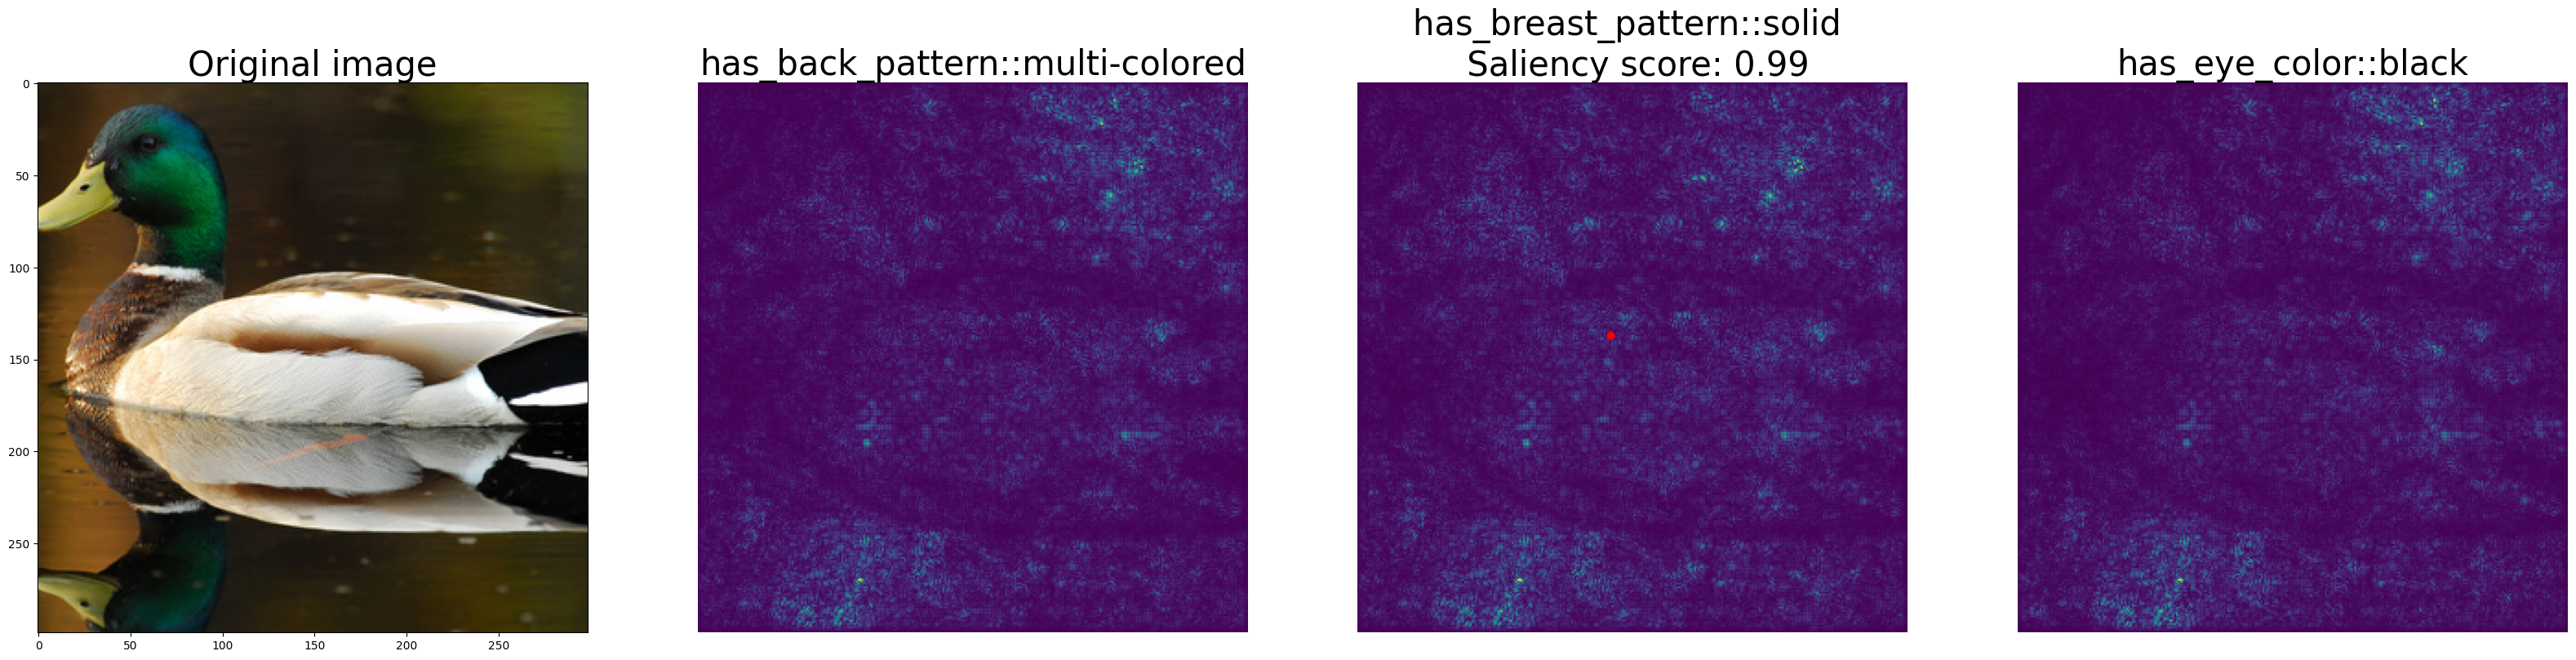

In [11]:
concept_list = [85,22,50]

XtoC_Model = torch.load(r'Original_models\Original_concepts\best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

sailency_maps = get_saliency_maps(X_original,concept_list,XtoC_Model,method_type='vanilla')#'noise_tunnel')

plot_sailency(img_original,sailency_maps,concept_list,concept_names,coordinates)


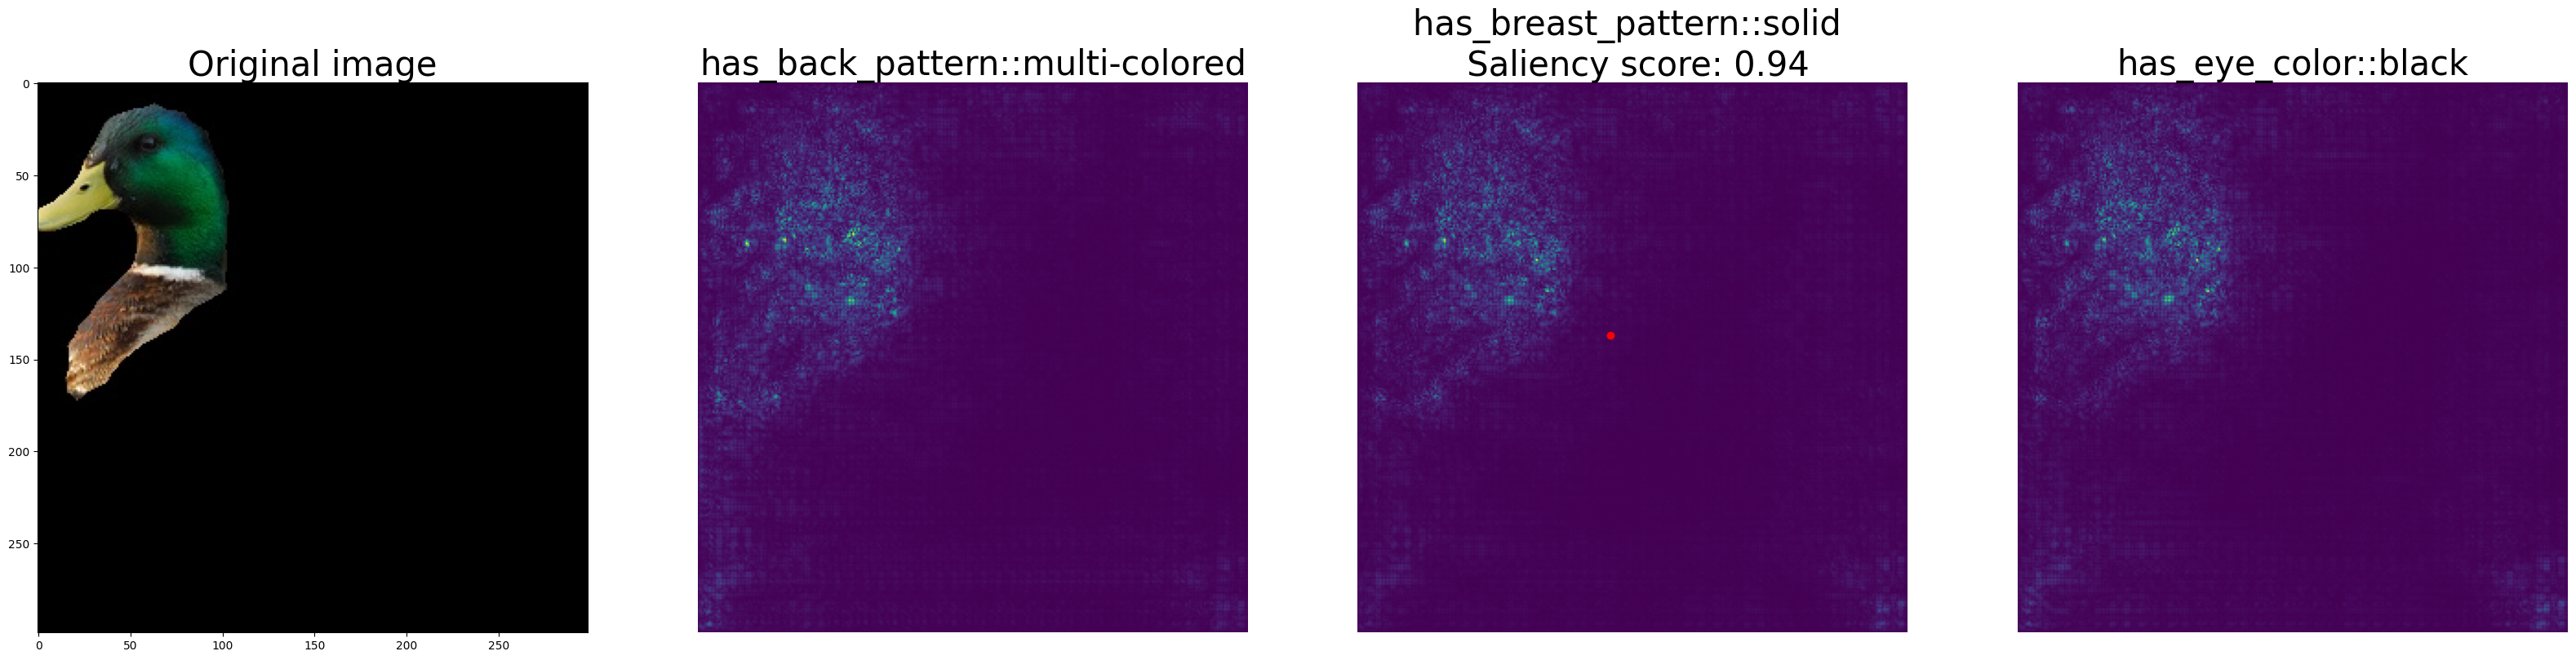

In [12]:

XtoC_Model = torch.load(r'Original_models\Original_concepts\best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

#Make temps names
#coordinates_temp = [coordinates[i] for i in mask]
#concept_names_temp = concept_names[mask] 
sailency_maps = get_saliency_maps(X_manipulated,concept_list,XtoC_Model,method_type='vanilla')

plot_sailency(img_manipulated,sailency_maps,concept_list,concept_names,coordinates)

In [13]:
#print full df
display_scrollable_dataframe(Full_df)

,Concept,Label,Majority Label,Original,Minipulated,NoN-MV Label distribution,MV label ditribution
0,has_bill_shape::dagger,False,False,-11.950000,-6.15,0.134968,0.085
1,has_bill_shape::hooked_seabird,False,False,-12.910000,-5.74,0.063709,0.060
2,has_bill_shape::all-purpose,False,False,-10.330000,-5.86,0.391754,0.405
3,has_bill_shape::cone,False,False,-10.350000,-5.89,0.261452,0.245
4,has_wing_color::brown,True,False,-9.810000,-6.27,0.269681,0.245
5,has_wing_color::grey,False,False,-11.480000,-6.02,0.300390,0.230
6,has_wing_color::yellow,False,False,-14.440000,-8.06,0.091703,0.060
7,has_wing_color::black,False,False,-9.950000,-5.76,0.428487,0.410
8,has_wing_color::white,True,True,9.980000,5.43,0.260774,0.205
9,has_wing_color::buff,True,False,-12.330000,-7.84,0.182474,0.130


In [14]:
print(Selected_df.to_latex(index=False))

NameError: name 'Selected_df' is not defined

In [ ]:
display_scrollable_dataframe(Full_df.sort_values(by=['Majority Label',"Label"],ascending=False))

In [ ]:
df=pd.DataFrame(Concept_dict).sort_values(by=['Majority Label',"Label"],ascending=False)
latex_table = df.to_latex(index=False)
print(latex_table)